# Section 1: Project Setup

## Objective

This notebook trains the QuantFormer Temporal Fusion Transformer (TFT) model on the processed FI-2010 Level-2 Limit Order Book dataset.

### Workflow

- Import project modules
- Load processed dataset
- Create DataLoaders
- Initialize QuantFormer
- Train the model
- Evaluate performance
- Save the best checkpoint

Unlike previous notebooks, the model architecture and training utilities are implemented inside the `src/` package to maintain a clean and reusable project structure.

In [1]:
import os
import sys

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print("Project Root :", PROJECT_ROOT)

Project Root : d:\Coding\Quant Former


In [2]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from pathlib import Path

In [3]:
import torch
import torch.nn as nn

from torch.utils.data import DataLoader

In [4]:
from src.config import *

from src.data.dataset import FI2010Dataset

from src.models.tft_model import (
    TemporalFusionTransformer
)

from src.training.train import (
    train_model,
    DEVICE
)

from src.training.visualization import (
    plot_training_history
)

from src.training.evaluation import (
    evaluate_predictions
)

Using Device : cpu


In [5]:
print("QuantFormer")

print("PyTorch Version :", torch.__version__)
print("Device          :", DEVICE)


QuantFormer
PyTorch Version : 2.13.0+cpu
Device          : cpu


# Section 2: Load Processed FI-2010 Dataset

## Objective

In this section, we load the preprocessed FI-2010 dataset generated during Notebook 3.

The processed dataset consists of:

- Training features and labels
- Validation features and labels
- Test features and labels

These datasets have already been transformed into fixed-length sequences and are stored as NumPy arrays.

The data will be used to create PyTorch datasets and dataloaders in the next section.

In [6]:
# ==========================================================
# Dataset Paths
# ==========================================================

from pathlib import Path

DATASET_DIR = Path("../datasets/processed/FI2010")

TRAIN_FEATURES = DATASET_DIR / "X_train.npy"
TRAIN_LABELS = DATASET_DIR / "y_train.npy"

VAL_FEATURES = DATASET_DIR / "X_val.npy"
VAL_LABELS = DATASET_DIR / "y_val.npy"

TEST_FEATURES = DATASET_DIR / "X_test.npy"
TEST_LABELS = DATASET_DIR / "y_test.npy"

print("Dataset Directory:")
print(DATASET_DIR.resolve())

Dataset Directory:
D:\Coding\Quant Former\datasets\processed\FI2010


In [7]:
import numpy as np

X_train = np.load(TRAIN_FEATURES, mmap_mode='r')
y_train = np.load(TRAIN_LABELS)

X_val = np.load(VAL_FEATURES, mmap_mode='r')
y_val = np.load(VAL_LABELS)

X_test = np.load(TEST_FEATURES, mmap_mode='r')
y_test = np.load(TEST_LABELS)

print("Dataset Loaded Successfully.")

Dataset Loaded Successfully.


In [8]:
print(f"Training Features   : {X_train.shape}")
print(f"Training Labels     : {y_train.shape}")

print()

print(f"Validation Features : {X_val.shape}")
print(f"Validation Labels   : {y_val.shape}")

print()

print(f"Test Features       : {X_test.shape}")
print(f"Test Labels         : {y_test.shape}")


Training Features   : (289821, 100, 143)
Training Labels     : (289821,)

Validation Features : (72381, 100, 143)
Validation Labels   : (72381,)

Test Features       : (31838, 100, 143)
Test Labels         : (31838,)


In [9]:
print("Feature Data Type :", X_train.dtype)
print("Label Data Type   :", y_train.dtype)

print()

print("Sequence Length   :", X_train.shape[1])
print("Number of Features:", X_train.shape[2])

print()

print("Unique Classes    :", np.unique(y_train))

Feature Data Type : float32
Label Data Type   : int64

Sequence Length   : 100
Number of Features: 143

Unique Classes    : [0 1 2]


## Observation

The processed FI-2010 dataset has been successfully loaded.

Key observations:

- Each sample contains a sequence of 100 order book snapshots.
- Every snapshot contains 143 numerical features.
- The prediction task is a three-class classification problem:
  - Class 0: Down
  - Class 1: Stable
  - Class 2: Up

The dataset is now ready to be converted into PyTorch datasets and dataloaders for model training.

# Section 3: Create PyTorch Dataset & DataLoaders

## Objective

In this section, the processed FI-2010 NumPy arrays are converted into PyTorch Dataset objects using the custom `FI2010Dataset` class.

The datasets are then wrapped into PyTorch DataLoaders to enable efficient mini-batch training, validation, and testing.

Using DataLoaders improves memory efficiency by loading data in batches instead of processing the entire dataset simultaneously.

In [10]:
train_dataset = FI2010Dataset(
    X_train,
    y_train
)

val_dataset = FI2010Dataset(
    X_val,
    y_val
)

test_dataset = FI2010Dataset(
    X_test,
    y_test
)

print("PyTorch Dataset Objects Created Successfully.")

PyTorch Dataset Objects Created Successfully.


In [11]:
BATCH_SIZE = 128

NUM_WORKERS = 0

PIN_MEMORY = torch.cuda.is_available()

print(f"Batch Size  : {BATCH_SIZE}")
print(f"Pin Memory  : {PIN_MEMORY}")
print(f"Workers     : {NUM_WORKERS}")

Batch Size  : 128
Pin Memory  : False
Workers     : 0


In [12]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

print("DataLoaders Created Successfully.")

DataLoaders Created Successfully.


In [13]:
features, labels = next(iter(train_loader))

print("=" * 60)

print("Feature Batch Shape :", features.shape)

print("Label Batch Shape   :", labels.shape)

print()

print("Feature Data Type   :", features.dtype)

print("Label Data Type     :", labels.dtype)

Feature Batch Shape : torch.Size([128, 100, 143])
Label Batch Shape   : torch.Size([128])

Feature Data Type   : torch.float32
Label Data Type     : torch.int64


In [14]:
# ==========================================================
# Dataset Summary
# ==========================================================

print("=" * 60)

print(f"Training Samples   : {len(train_dataset):,}")

print(f"Validation Samples : {len(val_dataset):,}")

print(f"Test Samples       : {len(test_dataset):,}")

print()

print(f"Training Batches   : {len(train_loader)}")

print(f"Validation Batches : {len(val_loader)}")

print(f"Test Batches       : {len(test_loader)}")

print("=" * 60)

Training Samples   : 289,821
Validation Samples : 72,381
Test Samples       : 31,838

Training Batches   : 2265
Validation Batches : 566
Test Batches       : 249


## Observation

The processed FI-2010 dataset has been successfully converted into PyTorch Dataset objects and DataLoaders.

Key observations:

- Mini-batches of 128 samples are generated efficiently.
- Each input batch has the shape `(Batch Size, Sequence Length, Number of Features)`.
- Labels are stored as integer class indices for multi-class classification.
- DataLoaders enable efficient batch-wise processing during training and evaluation while reducing memory usage.

# Section 4: Initialize QuantFormer Model

## Objective

In this section, we initialize the QuantFormer Temporal Fusion Transformer (TFT) model.

The model architecture consists of:

- Input Projection Layer
- LSTM Encoder
- Gated Residual Network (GRN)
- Interpretable Multi-Head Attention
- Gate Add & Layer Normalization
- Classification Head

The initialized model is transferred to the available computation device (CPU/GPU) and verified before training.

In [15]:
# ==========================================================
# Initialize QuantFormer Model
# ==========================================================

model = TemporalFusionTransformer()

model = model.to(DEVICE)

print("Model initialized successfully.")
print(f"Running on : {DEVICE}")

Model initialized successfully.
Running on : cpu


In [16]:
print(model)

TemporalFusionTransformer(
  (input_projection): InputProjection(
    (projection): Linear(in_features=143, out_features=128, bias=True)
  )
  (position_encoding): PositionalEncoding()
  (encoder): LSTMEncoder(
    (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.2)
  )
  (grn): GatedResidualNetwork(
    (fc1): Linear(in_features=128, out_features=128, bias=True)
    (activation): ELU(alpha=1.0)
    (fc2): Linear(in_features=128, out_features=128, bias=True)
    (dropout): Dropout(p=0.2, inplace=False)
    (skip): Identity()
    (gate_add_norm): GateAddNorm(
      (glu): GLU(
        (linear): Linear(in_features=128, out_features=128, bias=True)
        (gate): Linear(in_features=128, out_features=128, bias=True)
      )
      (layer_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    )
  )
  (attention): InterpretableMultiHeadAttention(
    (query): Linear(in_features=128, out_features=128, bias=True)
    (key): Linear(in_features=128, out_featu

In [17]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("=" * 60)

print(f"Total Parameters      : {total_params:,}")

print(f"Trainable Parameters  : {trainable_params:,}")


Total Parameters      : 654,723
Trainable Parameters  : 654,723


In [18]:
# ==========================================================
# Forward Pass Test
# ==========================================================

model.eval()

with torch.no_grad():

    sample_features, sample_labels = next(iter(train_loader))

    sample_features = sample_features.to(DEVICE)

    logits, attention = model(sample_features)

print("=" * 60)

print("Input Shape        :", sample_features.shape)

print("Logits Shape       :", logits.shape)

print("Attention Shape    :", attention.shape)

print("=" * 60)

Input Shape        : torch.Size([128, 100, 143])
Logits Shape       : torch.Size([128, 3])
Attention Shape    : torch.Size([128, 4, 100, 100])


In [19]:
# ==========================================================
# Prediction Check
# ==========================================================

probabilities = torch.softmax(
    logits,
    dim=1
)

predictions = torch.argmax(
    probabilities,
    dim=1
)

print("First 10 Predictions")

print(predictions[:10].cpu().numpy())

First 10 Predictions
[2 2 2 2 2 2 2 2 2 2]


## Observation

The QuantFormer model has been successfully initialized and transferred to the selected computation device.

A forward pass using a mini-batch from the training dataset confirms that:

- The input data is correctly processed.
- The model produces logits for three market movement classes.
- The attention mechanism executes successfully.
- The architecture is ready for optimization and training.

The next section configures the optimizer, learning rate scheduler, and loss function before starting the training process.

# Section 5: Configure Training

## Objective

This section defines the training configuration for the QuantFormer model.

The following components are initialized:

- Cross-Entropy Loss
- Adam Optimizer
- Learning Rate Scheduler
- Model Checkpoint Directory
- Training Hyperparameters

These configurations will be used during the training process in the next section.

In [20]:
criterion = nn.CrossEntropyLoss()

print("Loss Function :", criterion)

Loss Function : CrossEntropyLoss()


In [21]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print("Optimizer Initialized Successfully.")

Optimizer Initialized Successfully.


In [22]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3,
)

print("Learning Rate Scheduler Ready.")

Learning Rate Scheduler Ready.


In [23]:
from pathlib import Path

CHECKPOINT_DIR = Path("../checkpoints")

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODEL_PATH = CHECKPOINT_DIR / "best_tft_model.pth"

print("Checkpoint Path:")
print(MODEL_PATH.resolve())

Checkpoint Path:
D:\Coding\Quant Former\checkpoints\best_tft_model.pth


In [24]:
print("Training Configuration")

print("-" * 60)

print(f"Device          : {DEVICE}")
print(f"Batch Size      : {BATCH_SIZE}")
print(f"Epochs          : {EPOCHS}")
print(f"Learning Rate   : {LEARNING_RATE}")
print(f"Weight Decay    : {WEIGHT_DECAY}")
print(f"Loss Function   : {criterion.__class__.__name__}")
print(f"Optimizer       : {optimizer.__class__.__name__}")

print("-" * 60)

Training Configuration
------------------------------------------------------------
Device          : cpu
Batch Size      : 128
Epochs          : 20
Learning Rate   : 0.0001
Weight Decay    : 1e-05
Loss Function   : CrossEntropyLoss
Optimizer       : Adam
------------------------------------------------------------


## Observation

The QuantFormer training configuration has been successfully initialized.

The model will be optimized using the Adam optimizer with Cross-Entropy Loss for the three-class price movement prediction task.

A learning rate scheduler has been configured to reduce the learning rate automatically when the validation loss stops improving.

The best-performing model will be saved as a checkpoint for later evaluation and multimodal integration.

# Section 6: Train the QuantFormer Model

## Objective

This section trains the QuantFormer Temporal Fusion Transformer using the processed FI-2010 dataset.

The complete training pipeline has been implemented in the `src/training/train.py` module.

During training, the following are performed:

- Forward propagation
- Loss computation
- Backpropagation
- Weight optimization
- Validation after every epoch
- Learning rate scheduling
- Automatic checkpoint saving
- Training history collection

The model with the highest validation accuracy is automatically saved for later evaluation.

In [25]:
history, best_accuracy = train_model(

    model=model,

    train_loader=train_loader,

    val_loader=val_loader,

    optimizer=optimizer,

    scheduler=scheduler,

    criterion=criterion,

    epochs=EPOCHS,

    save_path=MODEL_PATH

)

Epoch 1/20


Train Loss       : 0.8180
Train Accuracy   : 0.6198
Validation Loss  : 0.8439
Validation Acc   : 0.6192
Learning Rate    : 0.000100
Best model checkpoint saved.

Epoch 2/20


Train Loss       : 0.6662
Train Accuracy   : 0.7171
Validation Loss  : 0.7859
Validation Acc   : 0.6508
Learning Rate    : 0.000100
Best model checkpoint saved.

Epoch 3/20


Train Loss       : 0.5767
Train Accuracy   : 0.7628
Validation Loss  : 0.6304
Validation Acc   : 0.7397
Learning Rate    : 0.000100
Best model checkpoint saved.

Epoch 4/20


Train Loss       : 0.4946
Train Accuracy   : 0.8040
Validation Loss  : 0.5524
Validation Acc   : 0.7800
Learning Rate    : 0.000100
Best model checkpoint saved.

Epoch 5/20


...

Train Loss       : 0.2651
Train Accuracy   : 0.9043
Validation Loss  : 0.5033
Validation Acc   : 0.8336
Learning Rate    : 0.000050

Epoch 17/20


Train Loss       : 0.2603
Train Accuracy   : 0.9067
Validation Loss  : 0.4858
Validation Acc   : 0.8361
Learning Rate    : 0.000050

Epoch 18/20


Train Loss       : 0.2554
Train Accuracy   : 0.9080
Validation Loss  : 0.4867
Validation Acc   : 0.8357
Learning Rate    : 0.000025

Epoch 19/20


Train Loss       : 0.2426
Train Accuracy   : 0.9129
Validation Loss  : 0.5223
Validation Acc   : 0.8314
Learning Rate    : 0.000025

Epoch 20/20


Train Loss       : 0.2389
Train Accuracy   : 0.9143
Validation Loss  : 0.5236
Validation Acc   : 0.8370
Learning Rate    : 0.000025

Training Completed
Best Validation Accuracy : 0.8376


In [26]:
print("Training Completed Successfully")

print(f"Best Validation Accuracy : {best_accuracy:.4f}")

print(f"Model Saved At           : {MODEL_PATH}")


Training Completed Successfully
Best Validation Accuracy : 0.8376
Model Saved At           : ..\checkpoints\best_tft_model.pth


## Observation

The QuantFormer model has been successfully trained on the processed FI-2010 Level-2 Limit Order Book dataset.

During training:

- Training and validation loss were monitored.
- Validation accuracy was evaluated after every epoch.
- The learning rate scheduler adjusted the learning rate automatically based on validation loss.
- The best-performing model checkpoint was saved for future evaluation and deployment.

The collected training history will be used in the next section to visualize the model's learning behavior.

# Section 7: Visualize Training Results

## Objective

This section visualizes the learning behavior of the QuantFormer model during training.

The following metrics are plotted:

- Training Loss
- Validation Loss
- Training Accuracy
- Validation Accuracy
- Learning Rate

These plots help analyze convergence, detect overfitting, and evaluate the effectiveness of the optimization process.|

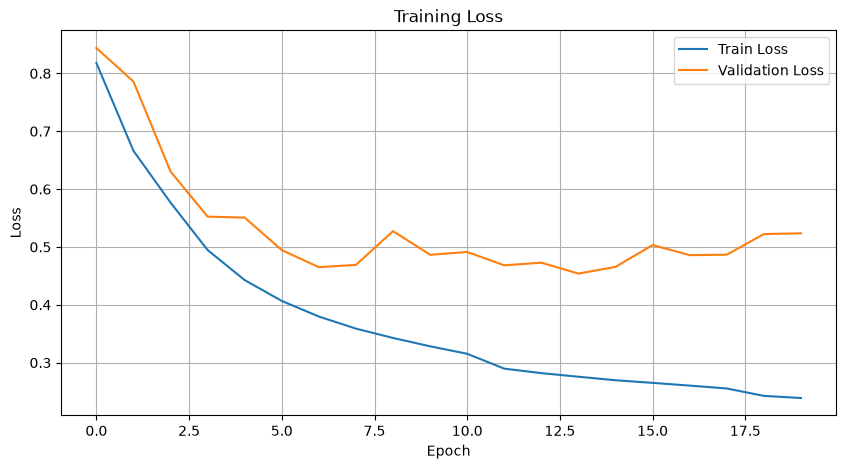

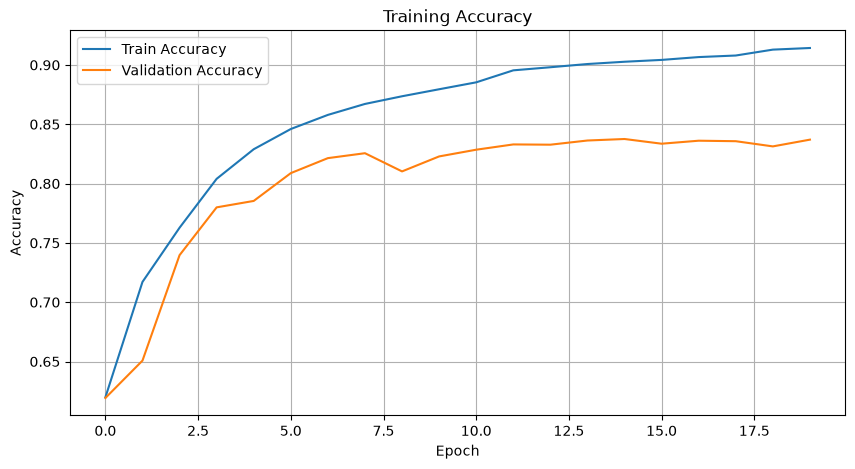

In [27]:
plot_training_history(history)

In [28]:
best_epoch = history["val_accuracy"].index(
    max(history["val_accuracy"])
) + 1

print("=" * 60)

print(f"Best Epoch                : {best_epoch}")

print(f"Best Validation Accuracy  : {max(history['val_accuracy']):.4f}")

print(f"Lowest Validation Loss    : {min(history['val_loss']):.4f}")

print("=" * 60)

Best Epoch                : 15
Best Validation Accuracy  : 0.8376
Lowest Validation Loss    : 0.4539


## Observation

The training curves provide insights into the learning dynamics of the QuantFormer model.

The validation accuracy and loss indicate the model's ability to generalize to unseen data. Monitoring these metrics helps identify convergence and detect potential overfitting.

The best-performing epoch will be used for final model evaluation in the next section.

# Section 8: Save Training Artifacts

## Objective

This section stores all important outputs generated during the training process.

The following artifacts are saved:

- Training History
- Training Metrics (CSV)
- Model Configuration
- Best Model Checkpoint (already saved during training)

These artifacts will be used in Notebook 6 for evaluation and performance analysis without retraining the model.

In [29]:
import os
import json
import pickle
import pandas as pd

In [30]:
ARTIFACT_DIR = "../artifacts"

os.makedirs(
    ARTIFACT_DIR,
    exist_ok=True
)

print("Artifacts Directory Created.")
print(ARTIFACT_DIR)

Artifacts Directory Created.
../artifacts


In [31]:
history_path = os.path.join(
    ARTIFACT_DIR,
    "training_history.pkl"
)

with open(history_path, "wb") as file:

    pickle.dump(
        history,
        file
    )

print("Training history saved.")

Training history saved.


In [32]:
history_df = pd.DataFrame(
    history
)

csv_path = os.path.join(
    ARTIFACT_DIR,
    "training_metrics.csv"
)

history_df.to_csv(
    csv_path,
    index=False
)

print("Training metrics CSV saved.")

Training metrics CSV saved.


In [33]:
config = {

    "batch_size": BATCH_SIZE,

    "epochs": EPOCHS,

    "learning_rate": LEARNING_RATE,

    "weight_decay": WEIGHT_DECAY,

    "sequence_length": SEQUENCE_LENGTH,

    "num_features": NUM_FEATURES,

    "hidden_size": HIDDEN_SIZE,

    "num_classes": NUM_CLASSES

}

config_path = os.path.join(
    ARTIFACT_DIR,
    "training_config.json"
)

with open(config_path, "w") as file:

    json.dump(
        config,
        file,
        indent=4
    )

print("Training configuration saved.")

Training configuration saved.


In [34]:
print("Saved Training Artifacts")


for file in os.listdir(ARTIFACT_DIR):

    print(file)


Saved Training Artifacts
fi2010_preprocessor.pkl
training_config.json
training_history.pkl
training_metrics.csv
train_finbert_embeddings.npy
val_finbert_embeddings.npy


## Notebook 5 Completed

The QuantFormer model has been successfully trained and all relevant training artifacts have been stored.

Saved artifacts include:

- Best model checkpoint
- Training history
- Training metrics
- Training configuration

These files will be used in Notebook 6 to evaluate the model on the FI-2010 test dataset and analyze its predictive performance.